In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
moldova_df = pd.read_csv('..dataset/moldova.csv')

## Loading stances

In [ ]:
with open('full_labeled_data.json', 'r') as f:
    data = json.load(f)
data

In [ ]:
column_names = ['pro_Russia', 'anti_Russia', 'neutral_Russia', 'pro_Europe', 'anti_Europe', 'neutral_Europe', 'non_relevant_Russia', 'non_relevant_Europe', '100_char', 'id', 'index']
gemini_df = pd.DataFrame(data, columns=column_names).set_index("index")

In [ ]:
moldova_df = moldova_df.merge(gemini_df, on="index", how='left')
moldova_df

output hidden for anonymization purposes

In [ ]:
moldova_df.to_csv('..dataset/moldova.csv', index=False)

In [ ]:
def getContrastingStances(row):
    stances = []
    if row['pro-Russia'] == 'yes':
        stances.append('pro-Russia')
    if row['anti-Russia'] == 'yes':
        stances.append('anti-Russia')

    if row['pro-Europe'] == 'yes':
        stances.append('pro-Europe')
    if row['anti-Europe'] == 'yes':
        stances.append('anti-Europe')

    if not stances:
        return 'neutral'
    elif len(stances) == 1:
        return stances[0]
    else:
        return ' & '.join(sorted(stances))

In [ ]:
moldova_df['contrasting_stance'] = moldova_df.apply(getContrastingStances, axis=1)


reddit = moldova_df[moldova_df['mediaType'] == 'Reddit']
facebook = moldova_df[moldova_df['mediaType'] == 'Facebook']
twitter = moldova_df[moldova_df['mediaType'] == 'Twitter']

## Stance distribution by platform

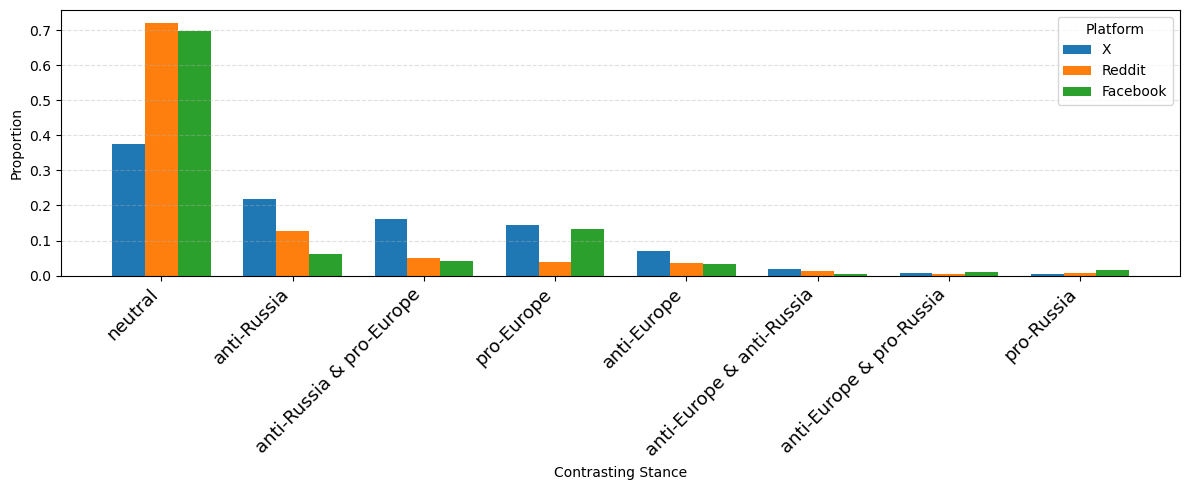

In [ ]:
# Derive stance order from Twitter (by frequency)
twitter_counts = twitter["contrasting_stance"].value_counts(normalize=True)

STANCE_ORDER = (
    twitter_counts[twitter_counts >= 0.003]
    .index
    .tolist()
)

def normalized_stance_distribution(df, stance_col, stance_order):
    counts = df[stance_col].value_counts()
    counts = counts.reindex(stance_order, fill_value=0)
    return counts / counts.sum()

# Compute distributions per platform
twitter_dist = normalized_stance_distribution(
    twitter, "contrasting_stance", STANCE_ORDER
)

reddit_dist = normalized_stance_distribution(
    reddit, "contrasting_stance", STANCE_ORDER
)

facebook_dist = normalized_stance_distribution(
    facebook, "contrasting_stance", STANCE_ORDER
)

x = np.arange(len(STANCE_ORDER))
width = 0.25

plt.figure(figsize=(12, 5))

plt.bar(
    x - width,
    twitter_dist.values,
    width,
    label="X",
    color="tab:blue",
)

plt.bar(
    x,
    reddit_dist.values,
    width,
    label="Reddit",
    color="tab:orange",
)

plt.bar(
    x + width,
    facebook_dist.values,
    width,
    label="Facebook",
    color="tab:green",
)

plt.xticks(x, STANCE_ORDER, rotation=45, ha="right", fontsize=13)
plt.ylabel("Proportion")
plt.xlabel("Contrasting Stance")
# plt.title("Normalized Stance Distribution by Platform")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Platform")

plt.tight_layout()
plt.show()


## Stance timeline

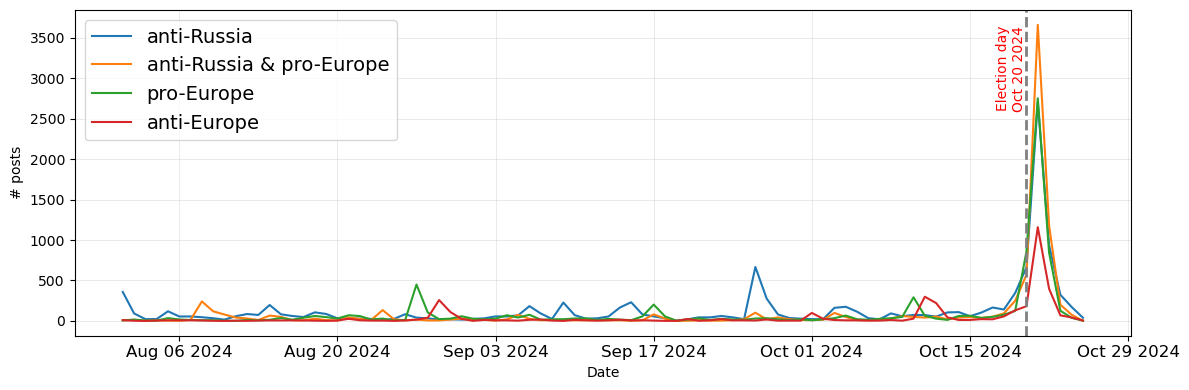

In [ ]:
DATE_COL = "timePublished"
STANCE_COL = "contrasting_stance"

STANCE_ORDER = [
    "anti-Russia",
    "anti-Russia & pro-Europe",
    "pro-Europe",
    "anti-Europe",
]

ELECTION_DAY = pd.Timestamp("2024-10-20")

df = moldova_df.copy()

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", utc=True)
df = df.dropna(subset=[DATE_COL, STANCE_COL])

df["day"] = df[DATE_COL].dt.floor("D")

daily_counts = (
    df[df[STANCE_COL].isin(STANCE_ORDER)]
      .groupby(["day", STANCE_COL])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=STANCE_ORDER, fill_value=0)
)


plt.figure(figsize=(12, 4))

for stance in STANCE_ORDER:
    plt.plot(daily_counts.index, daily_counts[stance], label=stance)

# plt.title("Posts stances over time")
plt.xlabel("Date")
plt.ylabel("# posts")
plt.xticks(fontsize=12)

plt.grid(
    which="major",
    axis="both",
    linestyle="-",
    linewidth=0.6,
    alpha=0.3
)

# Date ticks:
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # every 2 weeks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %Y"))

# Election day marker
plt.axvline(ELECTION_DAY, color="gray", linestyle="--",linewidth=2)
plt.text(
    ELECTION_DAY,
    plt.ylim()[1] * 0.95,
    "Election day\nOct 20 2024",
    color="red",
    rotation=90,
    va="top",
    ha="right",
)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()